# TSP-NLS pretrained reproduction

This notebook runs the unified DeepACO reproduction entry point for this problem. It writes logs, raw JSON, Markdown tables, and PNG figures to the repository-level output folders.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'pretrained').exists() else cwd.parent
sys.path.insert(0, str(ROOT))

from scripts.reproduce_problem import run_problem

PROBLEM = 'tsp_nls'
DEVICE = 'auto'          # 'auto', 'cpu', 'cuda', or 'cuda:0'
SEED = 12345
LIMIT_INSTANCES = None   # set to a small integer for a quick smoke test
SIZES = None             # e.g. [20] or None for all configured scales
T_ACO = None             # e.g. [1, 10] or None for paper-style checkpoints
METHODS = None           # e.g. ['deepaco'] or ['deepaco', 'aco']
INCLUDE_BASELINE = True


e:\DeepAoc\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
raw = run_problem(
    PROBLEM,
    sizes=SIZES,
    t_aco=T_ACO,
    methods=METHODS,
    limit_instances=LIMIT_INSTANCES,
    device=DEVICE,
    seed=SEED,
    include_baseline=INCLUDE_BASELINE,
)
raw['outputs']


[2026-05-10T17:09:33] Starting TSP-NLS reproduction
[2026-05-10T17:09:33] sizes=[100, 500, 1000], t_aco=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], methods=['deepaco'], device=cuda:0
[2026-05-10T17:09:39] TSP-NLS100: 1280/1280 instances, k_sparse=10
[2026-05-10T17:59:52] Finished TSP-NLS 100 DeepACO-NLS in 3012.27s
[2026-05-10T17:59:52] TSP-NLS500: 128/128 instances, k_sparse=50
[2026-05-10T19:05:44] Finished TSP-NLS 500 DeepACO-NLS in 3951.18s
[2026-05-10T19:05:44] TSP-NLS1000: 128/128 instances, k_sparse=100
[2026-05-11T00:05:02] Finished TSP-NLS 1000 DeepACO-NLS in 17957.85s
[2026-05-11T00:05:03] Wrote raw results: results/raw/tsp_nls_results.json
[2026-05-11T00:05:03] Wrote table: results/tables/tsp_nls_table.md
[2026-05-11T00:05:03] Wrote figure: results/figures/tsp_nls_comparison.png


{'raw': 'results/raw/tsp_nls_results.json',
 'table': 'results/tables/tsp_nls_table.md',
 'figure': 'results/figures/tsp_nls_comparison.png',
 'log': 'logs/tsp_nls.log'}

# TSP-NLS Reproduction Table

- Metric: average cost (lower is better)
- Instances per completed row: see `instances` column
- Device: cuda:0

| scale | method | status | instances | duration_s | T=1 | T=2 | T=3 | T=4 | T=5 | T=6 | T=7 | T=8 | T=9 | T=10 | gap_vs_aco_last |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 100 | DeepACO-NLS | ok | 1280 | 3012.27 | 7.77659 | 7.76974 | 7.76686 | 7.76497 | 7.76379 | 7.76293 | 7.7623 | 7.76179 | 7.76142 | 7.76104 |  |
| 500 | DeepACO-NLS | ok | 128 | 3951.18 | 16.978 | 16.9286 | 16.9075 | 16.8896 | 16.8752 | 16.8671 | 16.8576 | 16.8528 | 16.8493 | 16.8426 |  |
| 1000 | DeepACO-NLS | ok | 128 | 17957.85 | 24.0247 | 23.9429 | 23.9136 | 23.8879 | 23.8635 | 23.8504 | 23.8425 | 23.8323 | 23.8263 | 23.8211 |  |


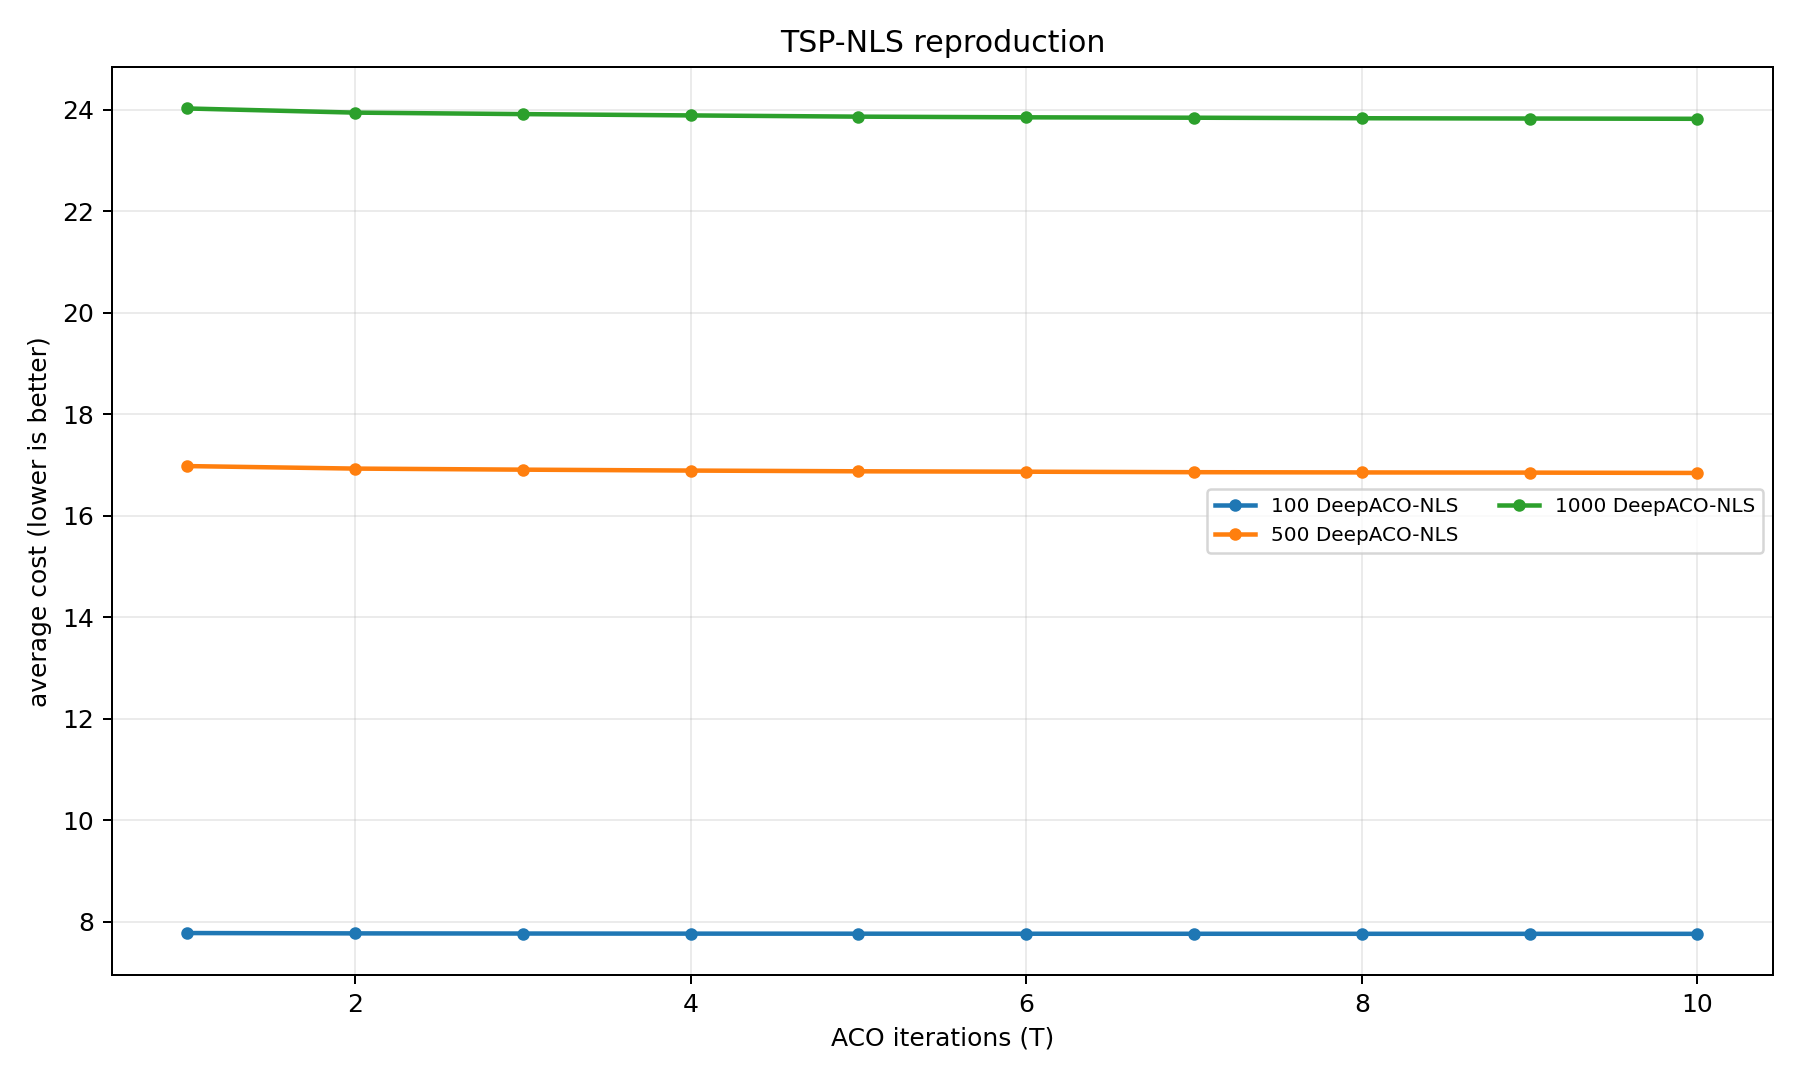

In [3]:
from IPython.display import Image, Markdown, display

outputs = raw['outputs'] if 'raw' in globals() else {
    'table': f'results/tables/{PROBLEM}_table.md',
    'figure': f'results/figures/{PROBLEM}_comparison.png',
}

table_path = ROOT / outputs['table']
figure_path = ROOT / outputs['figure']

display(Markdown(table_path.read_text(encoding='utf-8')))
display(Image(filename=str(figure_path)))
